# 03 — Dota 2 简单基线模型

**目标：** 使用前两份 notebook 确认的时间切分和特征工程，建立一个容易解释、容易复现的胜负预测基线。

本 notebook 会：

1. 重建相同的 side-aware 特征；
2. 训练多数类别 Dummy baseline；
3. 训练一个固定配置的 Logistic Regression；
4. 先比较验证集结果，再对测试集评估一次；
5. 报告 Accuracy、ROC-AUC 和 Log Loss；
6. 查看英雄系数，但只解释为相关性。

> 所有代码使用英文。本 notebook 不进行大规模调参，不训练复杂模型，也不保存部署模型。

## 为什么先建立简单基线？

基线模型回答的是：“复杂方法是否真的有必要？”

- 多数类别模型几乎不学习任何东西，是最低参考线；
- Logistic Regression 可以输出概率，训练快，系数可解释；
- 如果它不能稳定超过 Dummy baseline，应先重新检查数据和特征，而不是立刻增加模型复杂度。

测试集只用于最终评估，不参与模型选择。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from scipy.sparse import csr_matrix
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

SPLIT_ORDER = ["train", "validation", "test"]
TRAIN_CUTOFF = pd.Timestamp("2022-11-11 00:00:00")
VALIDATION_CUTOFF = pd.Timestamp("2023-11-19 08:14:29")
RANDOM_STATE = 42

print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

pandas: 3.0.3
NumPy: 2.5.1
scikit-learn: 1.9.0


## 1. 读取样本并恢复时间切分

为了让 notebook 可以独立运行，这里重复必要的读取和切分步骤。切分边界必须与 `02_feature_engineering.ipynb` 完全一致。

In [2]:
current_directory = Path.cwd().resolve()
root_candidates = [current_directory, current_directory.parent]
project_root = next(
    (candidate for candidate in root_candidates if (candidate / "data" / "processed").exists()),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not locate the project root. Run from dota2-ml-portfolio/ or notebooks/."
    )

data_path = project_root / "data" / "processed" / "dota2_matches_sample_30000.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Missing sample file: {data_path}")

df = pd.read_csv(data_path, parse_dates=["match_start_date_time"])
df["split"] = np.select(
    [
        df["match_start_date_time"] <= TRAIN_CUTOFF,
        df["match_start_date_time"] <= VALIDATION_CUTOFF,
    ],
    ["train", "validation"],
    default="test",
)

split_summary = (
    df.groupby("split", as_index=False)
    .agg(
        matches=("match_id", "size"),
        first_match=("match_start_date_time", "min"),
        last_match=("match_start_date_time", "max"),
        radiant_win_rate=("radiant_win", "mean"),
    )
)
split_summary["split"] = pd.Categorical(
    split_summary["split"], categories=SPLIT_ORDER, ordered=True
)
split_summary = split_summary.sort_values("split")

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns including split")
display(split_summary)

Loaded: 30,000 rows x 26 columns including split


,split,matches,first_match,last_match,radiant_win_rate
1,train,21004,2011-08-17 00:00:00,2022-11-11 00:00:00,0.5135
2,validation,4496,2022-11-12 00:00:00,2023-11-19 08:14:29,0.5016
0,test,4500,2023-11-19 08:38:55,2024-10-15 01:28:24,0.5098


## 2. 重建经过验证的特征

这里复用上一份 notebook 的规则：

- 训练集定义英雄和版本词表；
- Radiant 英雄为 `+1`，Dire 英雄为 `-1`；
- 新英雄使用双方独立计数；
- 新版本进入 `patch_unknown`；
- 标签、ID、时间和 split 不进入特征矩阵。

In [3]:
hero_id_columns = [
    f"{side}_player_{slot}_hero_id"
    for side in ("radiant", "dire")
    for slot in range(1, 6)
]
train_mask = df["split"].eq("train")
train_hero_ids = sorted(
    pd.unique(df.loc[train_mask, hero_id_columns].to_numpy().ravel()).tolist()
)
train_patch_ids = sorted(df.loc[train_mask, "game_version_id"].unique().tolist())


def build_hero_features(frame, hero_vocabulary):
    vocabulary = pd.Index(hero_vocabulary, dtype="int64")
    matrix = np.zeros((len(frame), len(vocabulary)), dtype=np.int8)
    row_positions = np.arange(len(frame))
    unknown_counts = {
        "unknown_radiant_hero_count": np.zeros(len(frame), dtype=np.int8),
        "unknown_dire_hero_count": np.zeros(len(frame), dtype=np.int8),
    }

    for side, value in (("radiant", 1), ("dire", -1)):
        unknown_column = f"unknown_{side}_hero_count"
        for slot in range(1, 6):
            source_column = f"{side}_player_{slot}_hero_id"
            hero_values = frame[source_column].to_numpy(dtype="int64")
            vocabulary_positions = vocabulary.get_indexer(hero_values)
            known_mask = vocabulary_positions >= 0
            matrix[
                row_positions[known_mask], vocabulary_positions[known_mask]
            ] = value
            unknown_counts[unknown_column] += (~known_mask).astype(np.int8)

    hero_features = pd.DataFrame(
        matrix,
        index=frame.index,
        columns=[f"hero_{hero_id}" for hero_id in vocabulary],
    )
    unknown_features = pd.DataFrame(unknown_counts, index=frame.index)
    return hero_features, unknown_features


def build_patch_features(frame, patch_vocabulary):
    known_patch_mask = frame["game_version_id"].isin(patch_vocabulary)
    known_patch_values = frame["game_version_id"].where(known_patch_mask)
    categorical = pd.Categorical(
        known_patch_values, categories=patch_vocabulary
    )
    patch_features = pd.get_dummies(
        categorical, prefix="patch", dtype=np.int8
    )
    patch_features.index = frame.index
    patch_features["patch_unknown"] = (~known_patch_mask).astype(np.int8)
    return patch_features


hero_features, unknown_hero_features = build_hero_features(df, train_hero_ids)
patch_features = build_patch_features(df, train_patch_ids)
feature_matrix = pd.concat(
    [hero_features, unknown_hero_features, patch_features], axis=1
).astype(np.int8)
target = df["radiant_win"].astype(np.int8)

print(f"Hero vocabulary: {len(train_hero_ids)}")
print(f"Patch vocabulary: {len(train_patch_ids)}")
print(f"Feature matrix: {feature_matrix.shape}")

Hero vocabulary: 123
Patch vocabulary: 136
Feature matrix: (30000, 262)


In [4]:
hero_values = set(np.unique(hero_features.to_numpy()).tolist())
known_hero_counts = hero_features.ne(0).sum(axis=1)
unknown_hero_counts = unknown_hero_features.sum(axis=1)
patch_active_counts = patch_features.sum(axis=1)
forbidden_columns = {
    "match_id",
    "match_start_date_time",
    "split",
    "radiant_win",
    "winner_id",
}

pre_model_checks = pd.DataFrame(
    [
        ("No missing features", not feature_matrix.isna().any().any()),
        ("No duplicate feature columns", not feature_matrix.columns.duplicated().any()),
        ("Hero values are -1, 0, or 1", hero_values.issubset({-1, 0, 1})),
        (
            "Every row accounts for 10 hero picks",
            (known_hero_counts + unknown_hero_counts).eq(10).all(),
        ),
        ("Exactly one patch feature per row", patch_active_counts.eq(1).all()),
        (
            "No forbidden fields in features",
            forbidden_columns.isdisjoint(feature_matrix.columns),
        ),
        ("Feature and target indexes align", feature_matrix.index.equals(target.index)),
    ],
    columns=["check", "passed"],
)
pre_model_checks["status"] = np.where(
    pre_model_checks["passed"], "PASS", "REVIEW"
)
display(pre_model_checks.drop(columns="passed"))
assert pre_model_checks["passed"].all(), "Pre-model checks failed."

,check,status
0,No missing features,PASS
1,No duplicate feature columns,PASS
2,"Hero values are -1, 0, or 1",PASS
3,Every row accounts for 10 hero picks,PASS
4,Exactly one patch feature per row,PASS
5,No forbidden fields in features,PASS
6,Feature and target indexes align,PASS


## 3. 转换成稀疏训练矩阵

特征值大部分是零。CSR 稀疏矩阵只保存非零位置，更适合 Logistic Regression，也更接近后续可复用的训练流程。

In [5]:
X = csr_matrix(feature_matrix.to_numpy(dtype=np.float32))
y = target.to_numpy(dtype=np.int8)

split_positions = {
    split_name: np.flatnonzero(df["split"].eq(split_name).to_numpy())
    for split_name in SPLIT_ORDER
}

X_train = X[split_positions["train"]]
X_validation = X[split_positions["validation"]]
X_test = X[split_positions["test"]]
y_train = y[split_positions["train"]]
y_validation = y[split_positions["validation"]]
y_test = y[split_positions["test"]]

sparse_summary = pd.DataFrame(
    [
        ("train", X_train.shape[0], X_train.shape[1], X_train.nnz),
        ("validation", X_validation.shape[0], X_validation.shape[1], X_validation.nnz),
        ("test", X_test.shape[0], X_test.shape[1], X_test.nnz),
    ],
    columns=["split", "rows", "features", "nonzero_values"],
)
sparse_summary["density"] = sparse_summary["nonzero_values"] / (
    sparse_summary["rows"] * sparse_summary["features"]
)
display(sparse_summary)

,split,rows,features,nonzero_values,density
0,train,21004,262,231044,0.0420
1,validation,4496,262,49456,0.0420
2,test,4500,262,49500,0.0420


## 4. 训练 Dummy baseline

`DummyClassifier(strategy="prior")` 学习训练集类别比例，但忽略所有英雄和版本特征。它的作用不是获得好结果，而是提供一个必须超过的最低标准。

In [6]:
dummy_model = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)
dummy_model.fit(X_train, y_train)

print(f"Dummy classes: {dummy_model.classes_.tolist()}")
print(f"Training class prior: {dummy_model.class_prior_.round(4).tolist()}")

Dummy classes: [0, 1]
Training class prior: [0.4865, 0.5135]


## 5. 训练 Logistic Regression

模型配置在查看测试集之前固定：

- `C=1.0`：使用默认的 L2 正则化强度，限制过大的系数；
- `solver="liblinear"`：适合当前规模的二分类稀疏数据；
- `max_iter=1000`：给优化器足够的收敛空间。

这里不搜索超参数，避免把简单基线变成复杂实验。

In [7]:
logistic_model = LogisticRegression(
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
logistic_model.fit(X_train, y_train)

print(f"Iterations used: {logistic_model.n_iter_.tolist()}")
print(f"Input features: {logistic_model.n_features_in_}")
print(f"Classes: {logistic_model.classes_.tolist()}")

Iterations used: [5]
Input features: 262
Classes: [0, 1]


## 6. 先评估训练集和验证集

三个指标关注不同问题：

- **Accuracy**：以 0.5 为阈值，预测对了多少场；
- **ROC-AUC**：模型排序胜负的能力，0.5 接近随机；
- **Log Loss**：概率是否合理，过度自信的错误会受到更大惩罚，越低越好。

测试集暂时不参与这一阶段。

In [8]:
def evaluate_model(model, X_values, y_values, model_name, split_name):
    probabilities = model.predict_proba(X_values)[:, 1]
    predictions = (probabilities >= 0.5).astype(np.int8)
    metrics = {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_values, predictions),
        "roc_auc": roc_auc_score(y_values, probabilities),
        "log_loss": log_loss(y_values, probabilities, labels=[0, 1]),
    }
    return metrics, probabilities, predictions


validation_records = []
prediction_cache = {}

for model_name, model in (
    ("Dummy prior", dummy_model),
    ("Logistic regression", logistic_model),
):
    for split_name, X_values, y_values in (
        ("train", X_train, y_train),
        ("validation", X_validation, y_validation),
    ):
        metrics, probabilities, predictions = evaluate_model(
            model, X_values, y_values, model_name, split_name
        )
        validation_records.append(metrics)
        prediction_cache[(model_name, split_name)] = {
            "probabilities": probabilities,
            "predictions": predictions,
        }

validation_results = pd.DataFrame(validation_records)
display(validation_results)

,model,split,accuracy,roc_auc,log_loss
0,Dummy prior,train,0.5135,0.5000,0.6928
1,Dummy prior,validation,0.5016,0.5000,0.6934
2,Logistic regression,train,0.5704,0.5978,0.6774
3,Logistic regression,validation,0.5318,0.5441,0.6928


In [9]:
validation_comparison = (
    validation_results[validation_results["split"].eq("validation")]
    .set_index("model")
    .sort_values("roc_auc", ascending=False)
)
validation_gain = (
    validation_comparison.loc["Logistic regression", "roc_auc"]
    - validation_comparison.loc["Dummy prior", "roc_auc"]
)

display(validation_comparison)
print(f"Validation ROC-AUC gain over dummy: {validation_gain:.4f}")

,split,accuracy,roc_auc,log_loss
model,,,,
Logistic regression,validation,0.5318,0.5441,0.6928
Dummy prior,validation,0.5016,0.5000,0.6934


Validation ROC-AUC gain over dummy: 0.0441


**决策规则：** 只有当 Logistic Regression 在验证集的 ROC-AUC 高于 0.5，并且 Log Loss 不差于 Dummy baseline，才值得进行一次测试集评估。模型配置不会因为测试结果而修改。

In [10]:
logistic_validation = validation_comparison.loc["Logistic regression"]
dummy_validation = validation_comparison.loc["Dummy prior"]
validation_gate_passed = bool(
    logistic_validation["roc_auc"] > 0.5
    and logistic_validation["log_loss"] <= dummy_validation["log_loss"]
)

gate_summary = pd.DataFrame(
    [
        ("Validation ROC-AUC above 0.5", logistic_validation["roc_auc"] > 0.5),
        (
            "Validation Log Loss no worse than dummy",
            logistic_validation["log_loss"] <= dummy_validation["log_loss"],
        ),
    ],
    columns=["check", "passed"],
)
gate_summary["status"] = np.where(gate_summary["passed"], "PASS", "STOP")
display(gate_summary.drop(columns="passed"))
assert validation_gate_passed, "Validation gate failed; do not evaluate the test set."

,check,status
0,Validation ROC-AUC above 0.5,PASS
1,Validation Log Loss no worse than dummy,PASS


## 7. 固定模型后评估测试集一次

到这里模型、特征和阈值都已经固定。下面只评估，不再根据测试结果调整模型。

In [11]:
test_records = []

for model_name, model in (
    ("Dummy prior", dummy_model),
    ("Logistic regression", logistic_model),
):
    metrics, probabilities, predictions = evaluate_model(
        model, X_test, y_test, model_name, "test"
    )
    test_records.append(metrics)
    prediction_cache[(model_name, "test")] = {
        "probabilities": probabilities,
        "predictions": predictions,
    }

test_results = pd.DataFrame(test_records)
all_results = pd.concat(
    [validation_results, test_results], ignore_index=True
)
display(test_results.set_index("model"))

,split,accuracy,roc_auc,log_loss
model,,,,
Dummy prior,test,0.5098,0.5000,0.6930
Logistic regression,test,0.5247,0.5321,0.6949


## 8. 混淆矩阵

混淆矩阵显示在 0.5 阈值下，Radiant 和 Dire 胜利分别被预测成什么。它可以发现模型是否明显偏向某一阵营。

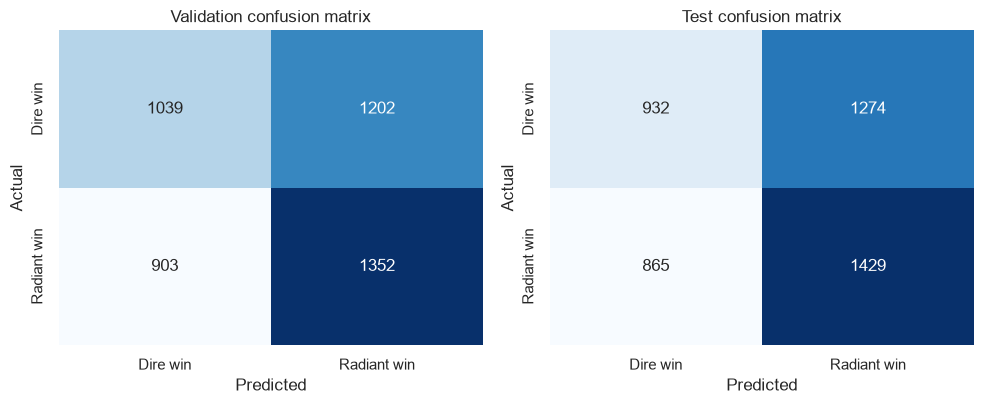

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

for ax, split_name, y_values in (
    (axes[0], "validation", y_validation),
    (axes[1], "test", y_test),
):
    predictions = prediction_cache[("Logistic regression", split_name)][
        "predictions"
    ]
    matrix = confusion_matrix(y_values, predictions, labels=[0, 1])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Dire win", "Radiant win"],
        yticklabels=["Dire win", "Radiant win"],
        ax=ax,
    )
    ax.set_title(f"{split_name.title()} confusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 9. ROC 曲线

ROC 曲线观察所有可能阈值下的排序能力。对角虚线代表随机排序；曲线越靠左上角越好。

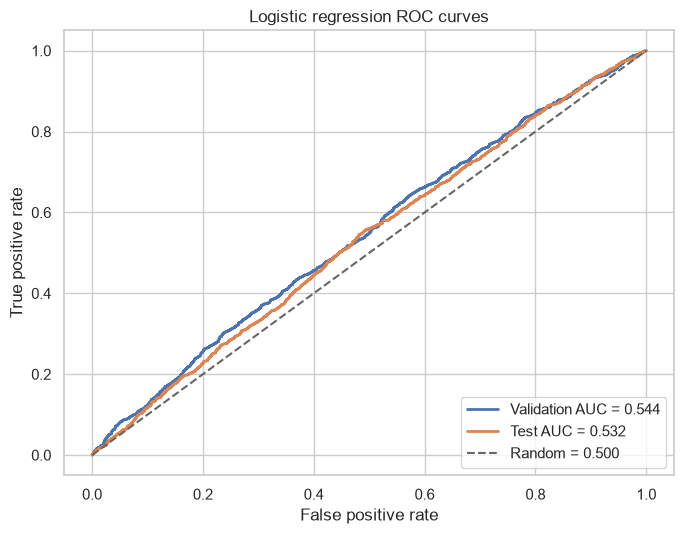

In [13]:
fig, ax = plt.subplots(figsize=(7, 5.5))

for split_name, y_values in (
    ("validation", y_validation),
    ("test", y_test),
):
    probabilities = prediction_cache[("Logistic regression", split_name)][
        "probabilities"
    ]
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_values, probabilities
    )
    auc_value = roc_auc_score(y_values, probabilities)
    ax.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=f"{split_name.title()} AUC = {auc_value:.3f}",
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="#666666", label="Random = 0.500")
ax.set_title("Logistic regression ROC curves")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. 解释英雄系数

因为英雄特征使用 `+1 / -1`：

- 正系数：该英雄在 Radiant 时与更高的 Radiant 胜率相关；在 Dire 时方向相反；
- 负系数：该英雄在 Radiant 时与更低的 Radiant 胜率相关；在 Dire 时方向相反。

这些系数受到版本、选手、队伍、英雄组合和抽样范围影响。它们是模型相关性，不是英雄强弱的因果证明。

,hero_id,hero_name,coefficient
97,99,Bristleback,-0.3166
73,75,Silencer,-0.2216
20,21,Windranger,-0.1836
85,87,Disruptor,-0.1772
24,26,Lion,-0.1636
106,108,Underlord,-0.1597
122,137,Primal Beast,-0.1574
113,119,Dark Willow,-0.1570
35,37,Warlock,-0.1372
92,94,Medusa,-0.1288


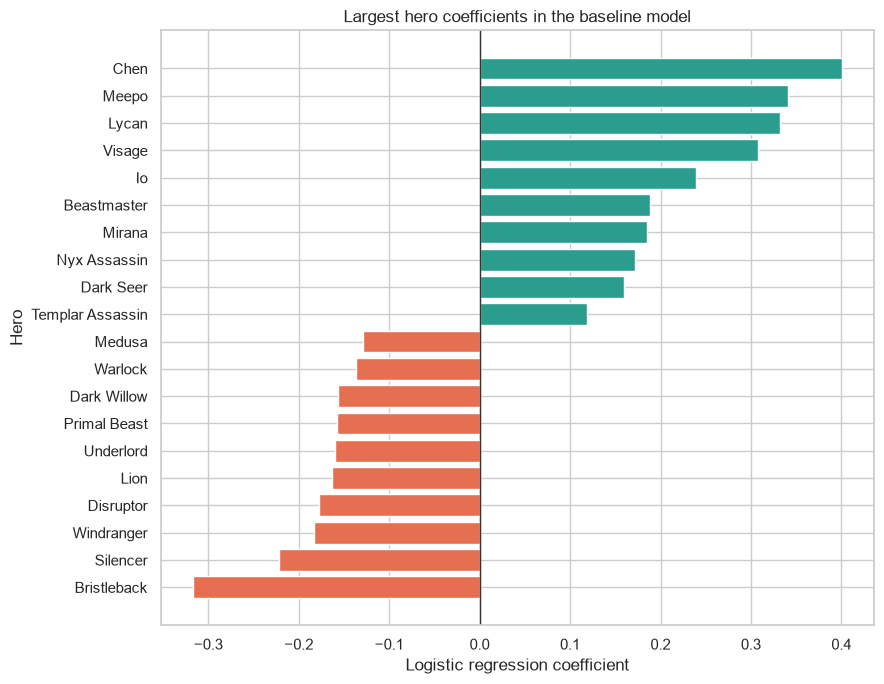

In [14]:
hero_lookup_frames = []
for side in ("radiant", "dire"):
    for slot in range(1, 6):
        id_column = f"{side}_player_{slot}_hero_id"
        name_column = f"{side}_player_{slot}_hero"
        hero_lookup_frames.append(
            df[[id_column, name_column]].rename(
                columns={id_column: "hero_id", name_column: "hero_name"}
            )
        )

hero_lookup = (
    pd.concat(hero_lookup_frames, ignore_index=True)
    .drop_duplicates("hero_id")
    .set_index("hero_id")["hero_name"]
)

coefficient_table = pd.DataFrame(
    {
        "feature": feature_matrix.columns,
        "coefficient": logistic_model.coef_[0],
    }
)
hero_coefficients = coefficient_table[
    coefficient_table["feature"].str.startswith("hero_")
].copy()
hero_coefficients["hero_id"] = (
    hero_coefficients["feature"].str.removeprefix("hero_").astype(int)
)
hero_coefficients["hero_name"] = hero_coefficients["hero_id"].map(hero_lookup)

strongest_heroes = pd.concat(
    [
        hero_coefficients.nsmallest(10, "coefficient"),
        hero_coefficients.nlargest(10, "coefficient"),
    ]
).sort_values("coefficient")
display(strongest_heroes[["hero_id", "hero_name", "coefficient"]])

coefficient_colors = np.where(
    strongest_heroes["coefficient"] >= 0, "#2A9D8F", "#E76F51"
)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    strongest_heroes["hero_name"],
    strongest_heroes["coefficient"],
    color=coefficient_colors,
)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Largest hero coefficients in the baseline model")
ax.set_xlabel("Logistic regression coefficient")
ax.set_ylabel("Hero")
plt.tight_layout()
plt.show()

## 11. 自动生成模型小结

小结数字来自已执行的模型结果。它不会把略高于随机的结果包装成高准确率系统。

In [15]:
test_comparison = test_results.set_index("model")
logistic_test = test_comparison.loc["Logistic regression"]
dummy_test = test_comparison.loc["Dummy prior"]
validation_test_auc_gap = (
    logistic_validation["roc_auc"] - logistic_test["roc_auc"]
)

summary_text = f'''
### Main baseline-model findings

- Dummy test metrics: **Accuracy {dummy_test['accuracy']:.3f}**, **ROC-AUC {dummy_test['roc_auc']:.3f}**, **Log Loss {dummy_test['log_loss']:.3f}**.
- Logistic-regression validation metrics: **Accuracy {logistic_validation['accuracy']:.3f}**, **ROC-AUC {logistic_validation['roc_auc']:.3f}**, **Log Loss {logistic_validation['log_loss']:.3f}**.
- Logistic-regression test metrics: **Accuracy {logistic_test['accuracy']:.3f}**, **ROC-AUC {logistic_test['roc_auc']:.3f}**, **Log Loss {logistic_test['log_loss']:.3f}**.
- Test ROC-AUC improvement over dummy: **{logistic_test['roc_auc'] - dummy_test['roc_auc']:.3f}**.
- Validation-to-test ROC-AUC gap: **{validation_test_auc_gap:.3f}**.
- The model used **{feature_matrix.shape[1]} features** and converged in **{int(logistic_model.n_iter_[0])} iterations**.
- Coefficients describe associations in this sample, not causal hero strength.
- No model artifact or deployment API was created.
'''
display(Markdown(summary_text))


### Main baseline-model findings

- Dummy test metrics: **Accuracy 0.510**, **ROC-AUC 0.500**, **Log Loss 0.693**.
- Logistic-regression validation metrics: **Accuracy 0.532**, **ROC-AUC 0.544**, **Log Loss 0.693**.
- Logistic-regression test metrics: **Accuracy 0.525**, **ROC-AUC 0.532**, **Log Loss 0.695**.
- Test ROC-AUC improvement over dummy: **0.032**.
- Validation-to-test ROC-AUC gap: **0.012**.
- The model used **262 features** and converged in **5 iterations**.
- Coefficients describe associations in this sample, not causal hero strength.
- No model artifact or deployment API was created.


## 下一步（本 notebook 不执行）

建议先完成项目报告，而不是立刻增加复杂模型：

1. 将最终验证和测试指标写入 README；
2. 说明模型只比随机好多少，以及为什么结果可能受到版本漂移影响；
3. 把特征转换函数提取到可测试的 Python 模块；
4. 再决定是否保存模型并创建一个简单阵容预测演示；
5. 如果继续实验，只在验证集比较新方案，不能反复查看测试集。

一个诚实、可复现、略高于基线的项目，比一个存在泄漏但分数很高的项目更适合作品集。